# Lab 7: Bagging, Boosting, and Stacking Ensemble Methods
## Objective
Build Bagging, Boosting, and Stacking classification models and evaluate their performance using appropriate metrics.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               AdaBoostClassifier, GradientBoostingClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load and Prepare Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')

feature_cols = df.columns[:-1]
X = df[feature_cols]
y = df['Class']
class_names = ['Kama', 'Rosa', 'Canadian']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing:  {X_test.shape[0]} samples")

Training: 168 samples
Testing:  42 samples


---
## Part A: Bagging

### 3. Bagging Classifier

In [3]:
# Bagging with Decision Tree as base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42
)
bagging_model.fit(X_train_scaled, y_train)

y_pred_bag = bagging_model.predict(X_test_scaled)

acc_bag = accuracy_score(y_test, y_pred_bag)
prec_bag = precision_score(y_test, y_pred_bag, average='weighted')
rec_bag = recall_score(y_test, y_pred_bag, average='weighted')
f1_bag = f1_score(y_test, y_pred_bag, average='weighted')

print("Bagging Classifier — Evaluation")
print("=" * 50)
print(f"Accuracy:  {acc_bag:.4f}")
print(f"Precision: {prec_bag:.4f}")
print(f"Recall:    {rec_bag:.4f}")
print(f"F1 Score:  {f1_bag:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bag, target_names=class_names))

Bagging Classifier — Evaluation
Accuracy:  0.9048
Precision: 0.9190
Recall:    0.9048
F1 Score:  0.9007

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.71      0.83        14
        Rosa       0.93      1.00      0.97        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42



### 4. Random Forest (Bagging Extension)

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest — Evaluation")
print("=" * 50)
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")

Random Forest — Evaluation
Accuracy:  0.9048
Precision: 0.9190
Recall:    0.9048
F1 Score:  0.9007


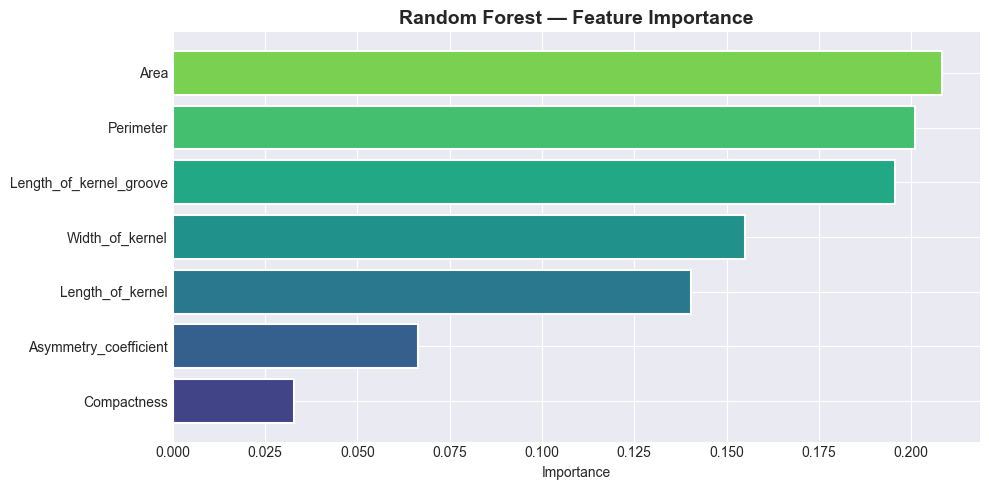

In [5]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df))),
        edgecolor='white', linewidth=1.5)
ax.set_title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## Part B: Boosting

### 5. AdaBoost Classifier

In [6]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42,
)
ada_model.fit(X_train_scaled, y_train)

y_pred_ada = ada_model.predict(X_test_scaled)

acc_ada = accuracy_score(y_test, y_pred_ada)
prec_ada = precision_score(y_test, y_pred_ada, average='weighted')
rec_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

print("AdaBoost — Evaluation")
print("=" * 50)
print(f"Accuracy:  {acc_ada:.4f}")
print(f"Precision: {prec_ada:.4f}")
print(f"Recall:    {rec_ada:.4f}")
print(f"F1 Score:  {f1_ada:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada, target_names=class_names))

AdaBoost — Evaluation
Accuracy:  0.8810
Precision: 0.8995
Recall:    0.8810
F1 Score:  0.8731

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.64      0.78        14
        Rosa       0.88      1.00      0.93        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42



### 6. Gradient Boosting Classifier

In [7]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb, average='weighted')
rec_gb = recall_score(y_test, y_pred_gb, average='weighted')
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

print("Gradient Boosting — Evaluation")
print("=" * 50)
print(f"Accuracy:  {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"Recall:    {rec_gb:.4f}")
print(f"F1 Score:  {f1_gb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=class_names))

Gradient Boosting — Evaluation
Accuracy:  0.9286
Precision: 0.9361
Recall:    0.9286
F1 Score:  0.9263

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.79      0.88        14
        Rosa       0.93      1.00      0.97        14
    Canadian       0.88      1.00      0.93        14

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



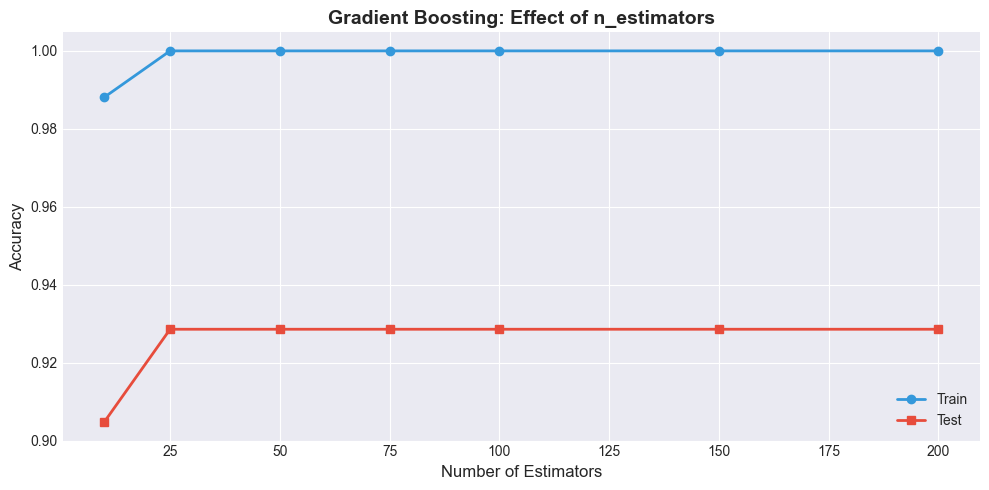

In [8]:
# Effect of number of estimators on Gradient Boosting
n_estimators_range = [10, 25, 50, 75, 100, 150, 200]
gb_train_scores = []
gb_test_scores = []

for n in n_estimators_range:
    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    gb.fit(X_train_scaled, y_train)
    gb_train_scores.append(gb.score(X_train_scaled, y_train))
    gb_test_scores.append(gb.score(X_test_scaled, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_estimators_range, gb_train_scores, 'o-', label='Train', color='#3498db', linewidth=2)
ax.plot(n_estimators_range, gb_test_scores, 's-', label='Test', color='#e74c3c', linewidth=2)
ax.set_xlabel('Number of Estimators', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Gradient Boosting: Effect of n_estimators', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part C: Stacking

### 7. Stacking Classifier

In [9]:
# Define base learners
base_estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('nb', GaussianNB()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
]

# Stacking with Logistic Regression as meta-learner
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)
stacking_model.fit(X_train_scaled, y_train)

y_pred_stack = stacking_model.predict(X_test_scaled)

acc_stack = accuracy_score(y_test, y_pred_stack)
prec_stack = precision_score(y_test, y_pred_stack, average='weighted')
rec_stack = recall_score(y_test, y_pred_stack, average='weighted')
f1_stack = f1_score(y_test, y_pred_stack, average='weighted')

print("Stacking Classifier — Evaluation")
print("=" * 50)
print(f"Base learners: KNN, Decision Tree, Naïve Bayes, SVM")
print(f"Meta-learner: Logistic Regression")
print(f"\nAccuracy:  {acc_stack:.4f}")
print(f"Precision: {prec_stack:.4f}")
print(f"Recall:    {rec_stack:.4f}")
print(f"F1 Score:  {f1_stack:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack, target_names=class_names))

Stacking Classifier — Evaluation
Base learners: KNN, Decision Tree, Naïve Bayes, SVM
Meta-learner: Logistic Regression

Accuracy:  0.8810
Precision: 0.8995
Recall:    0.8810
F1 Score:  0.8731

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.64      0.78        14
        Rosa       0.88      1.00      0.93        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42



### 8. Voting Classifier (Hard & Soft Voting)

In [10]:
# Hard Voting
voting_hard = VotingClassifier(
    estimators=base_estimators,
    voting='hard'
)
voting_hard.fit(X_train_scaled, y_train)
y_pred_vh = voting_hard.predict(X_test_scaled)
acc_vh = accuracy_score(y_test, y_pred_vh)

# Soft Voting
voting_soft = VotingClassifier(
    estimators=base_estimators,
    voting='soft'
)
voting_soft.fit(X_train_scaled, y_train)
y_pred_vs = voting_soft.predict(X_test_scaled)
acc_vs = accuracy_score(y_test, y_pred_vs)

print(f"Hard Voting Accuracy: {acc_vh:.4f}")
print(f"Soft Voting Accuracy: {acc_vs:.4f}")

Hard Voting Accuracy: 0.9048
Soft Voting Accuracy: 0.8810


## 9. Confusion Matrices (All Ensemble Models)

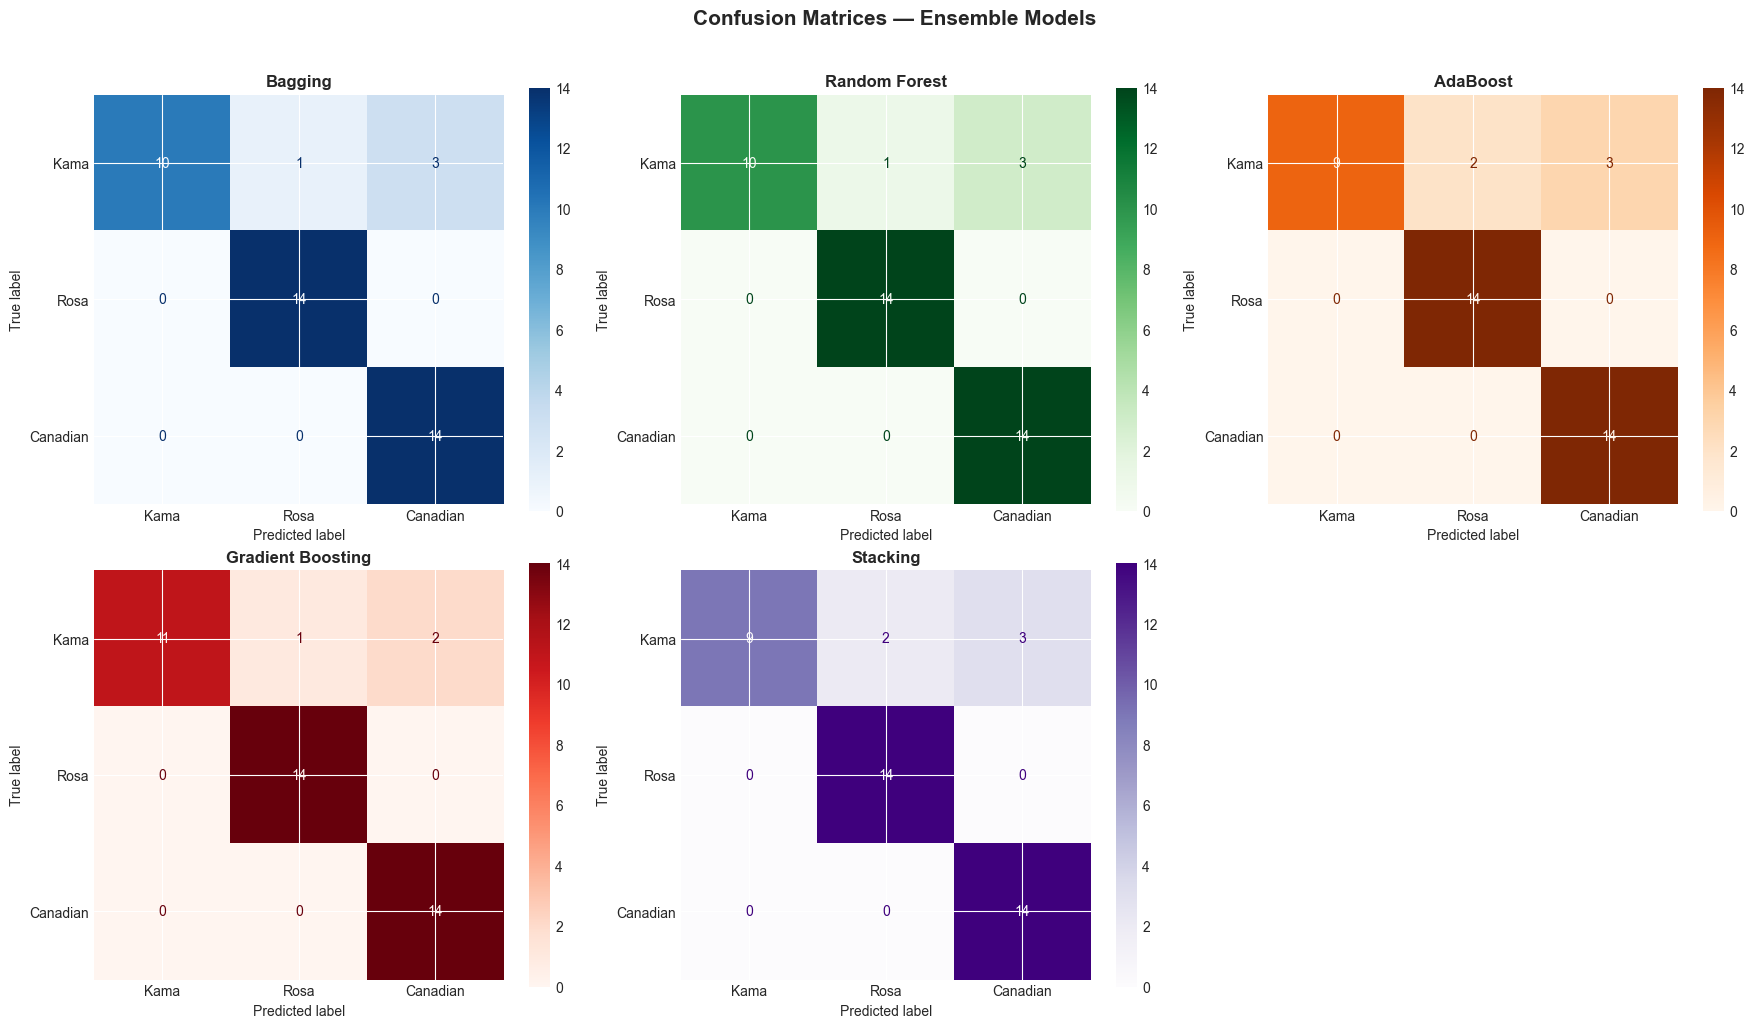

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

models_preds = [
    ('Bagging', y_pred_bag, 'Blues'),
    ('Random Forest', y_pred_rf, 'Greens'),
    ('AdaBoost', y_pred_ada, 'Oranges'),
    ('Gradient Boosting', y_pred_gb, 'Reds'),
    ('Stacking', y_pred_stack, 'Purples'),
]

for i, (name, pred, cmap) in enumerate(models_preds):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=cmap, ax=axes[i])
    axes[i].set_title(name, fontsize=12, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — Ensemble Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Comprehensive Comparison

In [12]:
# Cross-validation for all models
X_scaled_all = scaler.transform(X)

models = {
    'Bagging': bagging_model,
    'Random Forest': rf_model,
    'AdaBoost': ada_model,
    'Gradient Boosting': gb_model,
    'Stacking': stacking_model,
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled_all, y, cv=5, scoring='accuracy')
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test F1': f1_score(y_test, y_pred, average='weighted'),
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\nEnsemble Model Comparison")
print("=" * 65)
results_df


Ensemble Model Comparison


,Model,Test Accuracy,Test F1,CV Mean,CV Std
3,Gradient Boosting,0.928571,0.926284,0.895238,0.080531
0,Bagging,0.904762,0.900692,0.914286,0.061353
1,Random Forest,0.904762,0.900692,0.890476,0.115274
2,AdaBoost,0.880952,0.873056,0.904762,0.075292
4,Stacking,0.880952,0.873056,0.914286,0.077664


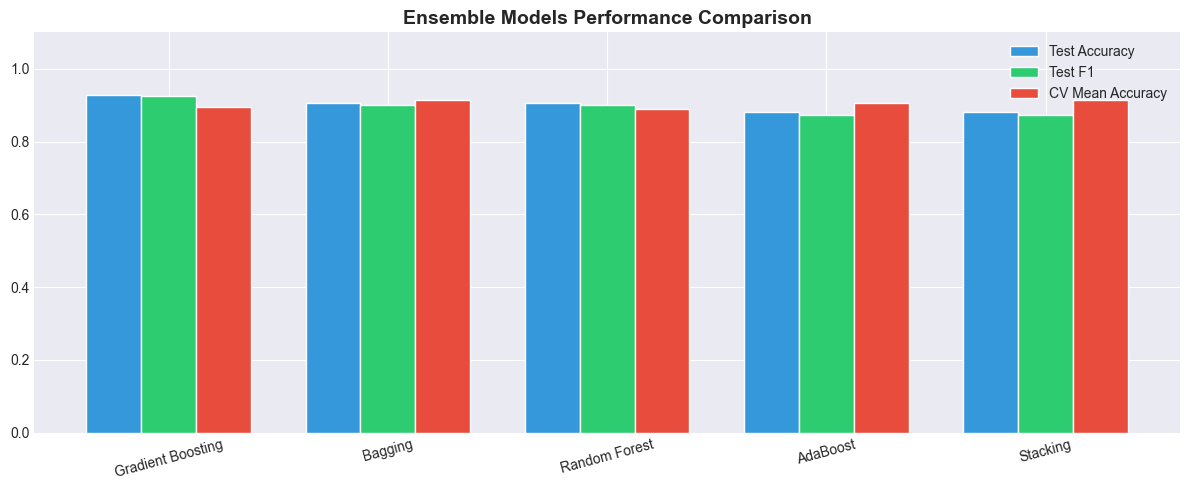

In [13]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['Test Accuracy'], width, label='Test Accuracy',
       color='#3498db', edgecolor='white')
ax.bar(x, results_df['Test F1'], width, label='Test F1',
       color='#2ecc71', edgecolor='white')
ax.bar(x + width, results_df['CV Mean'], width, label='CV Mean Accuracy',
       color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0, 1.1)
ax.set_title('Ensemble Models Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Conclusion
In this lab, we built and evaluated ensemble methods:
- **Bagging**: Reduces variance by training on bootstrap samples. Random Forest extends this.
- **Boosting**: AdaBoost and Gradient Boosting sequentially correct errors, reducing bias.
- **Stacking**: Combines diverse base learners using a meta-learner.
- **Voting**: Simple combination via majority vote (hard) or probability averaging (soft).
- Ensemble methods generally outperform individual classifiers by combining multiple perspectives.